# Predicción del Comportamiento de Compra de Clientes

## Descripción

Este proyecto utiliza técnicas de Machine Learning para predecir la probabilidad de que un cliente responda positivamente a una campaña de marketing.

## Objetivos

- Analizar los datos de clientes.
- Identificar patrones de comportamiento.
- Entrenar un modelo predictivo.
- Evaluar el rendimiento del modelo.

## Tecnologías

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

# Predicción del Comportamiento de Compra de Clientes

## Descripción

Este proyecto utiliza técnicas de Machine Learning para predecir la probabilidad de que un cliente responda positivamente a una campaña de marketing.

## Objetivos

- Analizar los datos de clientes.
- Identificar patrones de comportamiento.
- Entrenar un modelo predictivo.
- Evaluar el rendimiento del modelo.

## Tecnologías

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 1000

data = {
    "Year_Birth": np.random.randint(1950, 2000, n),
    "Education": np.random.choice(
        ["Basic", "Graduation", "Master", "PhD"],
        n
    ),
    "Marital_Status": np.random.choice(
        ["Single", "Married", "Divorced", "Together"],
        n
    ),
    "Income": np.random.randint(18000, 90000, n),
    "Kidhome": np.random.randint(0, 3, n),
    "Teenhome": np.random.randint(0, 3, n),
    "Recency": np.random.randint(1, 100, n),
    "MntWines": np.random.randint(0, 1000, n),
    "MntFruits": np.random.randint(0, 200, n),
    "MntMeatProducts": np.random.randint(0, 800, n),
    "MntFishProducts": np.random.randint(0, 400, n),
    "MntSweetProducts": np.random.randint(0, 250, n),
    "MntGoldProds": np.random.randint(0, 300, n),
    "NumDealsPurchases": np.random.randint(0, 10, n),
    "NumWebPurchases": np.random.randint(0, 15, n),
    "NumCatalogPurchases": np.random.randint(0, 10, n),
    "NumStorePurchases": np.random.randint(0, 12, n),
    "Response": np.random.randint(0, 2, n)
}

df = pd.DataFrame(data)

df.to_csv("marketing_campaign.csv", index=False)

df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Response
0,1988,Basic,Single,83450,1,0,48,497,121,646,277,212,185,9,5,2,2,0
1,1978,Basic,Married,28382,0,0,44,296,68,41,138,179,58,2,12,8,6,1
2,1964,Basic,Divorced,22437,2,2,24,133,22,675,175,83,0,7,10,7,8,0
3,1992,Graduation,Divorced,88971,1,1,61,330,180,282,7,67,130,5,9,5,9,1
4,1957,Basic,Married,82612,0,2,17,248,36,57,294,138,66,1,10,0,9,0


Carga de Datos

En esta sección se carga el conjunto de datos y se realiza una primera inspección de su estructura.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("marketing_campaign.csv")
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Response
0,1988,Basic,Single,83450,1,0,48,497,121,646,277,212,185,9,5,2,2,0
1,1978,Basic,Married,28382,0,0,44,296,68,41,138,179,58,2,12,8,6,1
2,1964,Basic,Divorced,22437,2,2,24,133,22,675,175,83,0,7,10,7,8,0
3,1992,Graduation,Divorced,88971,1,1,61,330,180,282,7,67,130,5,9,5,9,1
4,1957,Basic,Married,82612,0,2,17,248,36,57,294,138,66,1,10,0,9,0


In [ ]:
df.shape

(1000, 18)

Exploración Inicial de los Datos

Se analiza la estructura del dataset, el tipo de las variables y la presencia de valores nulos.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Year_Birth           1000 non-null   int64 
 1   Education            1000 non-null   object
 2   Marital_Status       1000 non-null   object
 3   Income               1000 non-null   int64 
 4   Kidhome              1000 non-null   int64 
 5   Teenhome             1000 non-null   int64 
 6   Recency              1000 non-null   int64 
 7   MntWines             1000 non-null   int64 
 8   MntFruits            1000 non-null   int64 
 9   MntMeatProducts      1000 non-null   int64 
 10  MntFishProducts      1000 non-null   int64 
 11  MntSweetProducts     1000 non-null   int64 
 12  MntGoldProds         1000 non-null   int64 
 13  NumDealsPurchases    1000 non-null   int64 
 14  NumWebPurchases      1000 non-null   int64 
 15  NumCatalogPurchases  1000 non-null   int64 
 16  NumStor

In [ ]:
df.loc[0:20, "Income"] = None

In [ ]:
df.isnull().sum()

,0
Year_Birth,0
Education,0
Marital_Status,0
Income,21
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0


In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0


In [ ]:
df = pd.concat([df, df.iloc[:10]])

 Limpieza y Preparación de Datos

Se eliminan registros duplicados y se gestionan los valores faltantes para mejorar la calidad de los datos.

In [ ]:
df.duplicated().sum()

np.int64(10)

In [ ]:
df = df.drop_duplicates()

Preprocesamiento de Datos

Las variables categóricas se transforman a formato numérico para que puedan ser utilizadas por los algoritmos de Machine Learning.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Education"] = le.fit_transform(df["Education"])
df["Marital_Status"] = le.fit_transform(df["Marital_Status"])

In [ ]:
X = df.drop("Response", axis=1)
y = df["Response"]

 División del Conjunto de Datos

El dataset se divide en datos de entrenamiento y prueba para evaluar correctamente el rendimiento del modelo.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1 Score:", f1_score(y_test, pred))

Accuracy: 0.5204081632653061
Precision: 0.4946236559139785
Recall: 0.4946236559139785
F1 Score: 0.4946236559139785


#  Análisis Exploratorio de Datos (EDA)

El objetivo es comprender mejor las características de los clientes y detectar posibles patrones antes de entrenar el modelo.

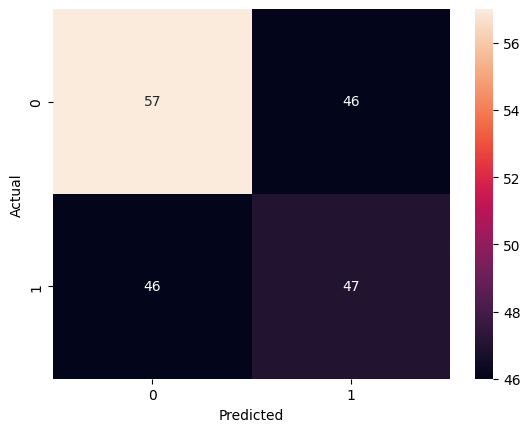

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


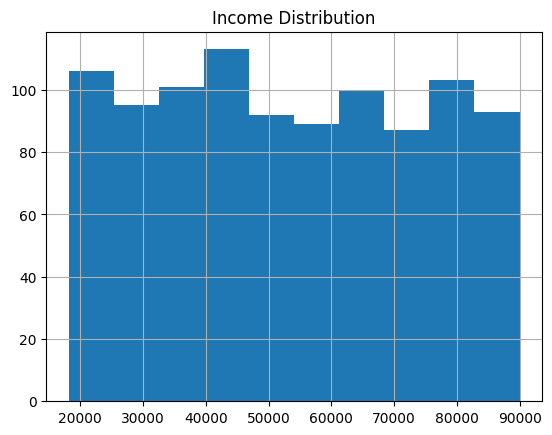

In [ ]:
df["Income"].hist()
plt.title("Income Distribution")
plt.show()

## Correlación entre Variables

La matriz de correlación permite identificar relaciones entre las variables numéricas del dataset.

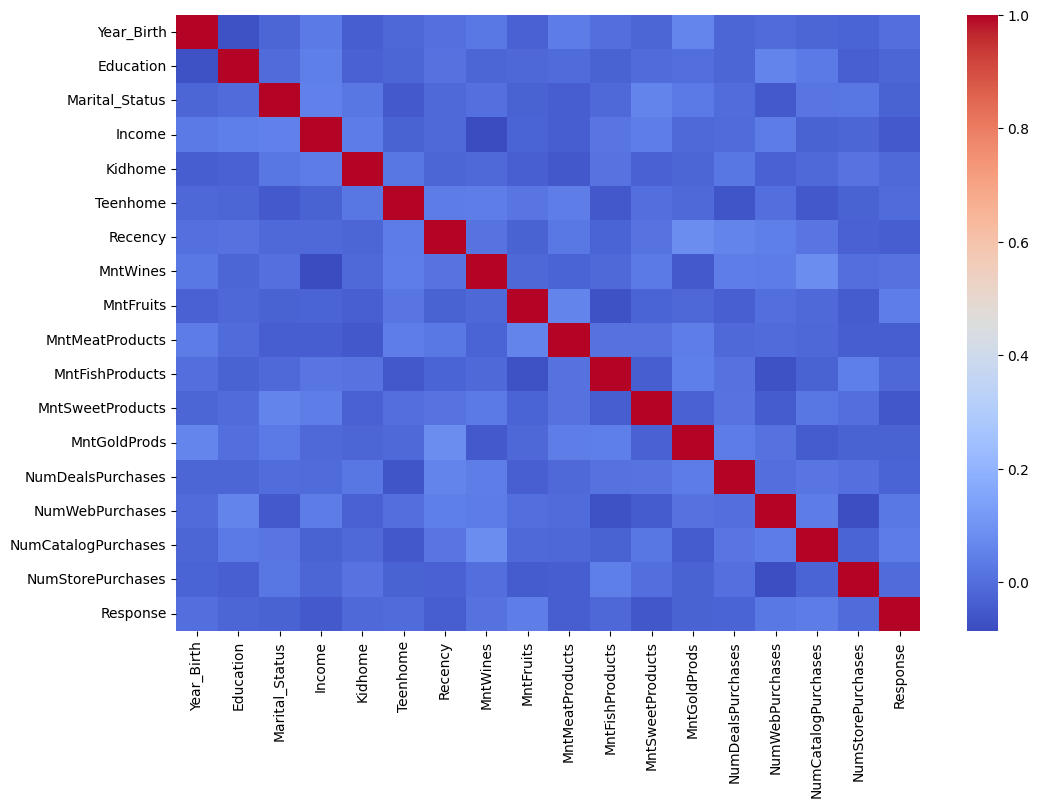

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

In [106]:
nuevo_cliente = [[
    1988,
    2,
    1,
    45000,
    1,
    0,
    20,
    300,
    50,
    200,
    100,
    80,
    60,
    3,
    5,
    2,
    4
]]

model.predict(nuevo_cliente)

array([0])